In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from venn_abers.venn_abers import VennAbersCV

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse_1718   = df[df["dataset"].isin(["HSE 2017", "HSE 2018"])].copy()
daphnie_24 = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"HSE 2017–2018: n = {len(hse_1718):,}")
print(f"DAPHNIE 2024:  n = {len(daphnie_24):,}")
print(f"Class ratio    DAPHNIE:HSE = 1:{len(hse_1718)/len(daphnie_24):.1f}")

HSE 2017–2018: n = 16,173
DAPHNIE 2024:  n = 5,237
Class ratio    DAPHNIE:HSE = 1:3.1


## Density Ratio Estimation — Restricted Pipeline

### Rationale

This notebook is the definitive density ratio estimation for the norm derivation
pipeline. It differs from notebook 03 in three ways:

- **Source:** DAPHNIE 2024 only. DAPHNIE 2023 is a pilot with anomalous employment
  composition and is excluded from norm derivation.
- **Target:** HSE 2017–2018 only (n ≈ 16,173). HSE 2019 is excluded because it has
  no EQ-5D-5L outcome data. Notebook 011 confirmed HSE 2017 and 2018 are consistent.
- **Predictor set:** 15 variables — the 13-variable notebook 03 set extended with
  `resp` and `skin`, both 0% missing in HSE 2017–18 and DAPHNIE 2024 once HSE 2019
  is excluded. `alcohol_yr` is excluded from the model (skip-logic artefact) but
  appears in the balance check as a diagnostic.

The density ratio weights produced here are the ones used in notebook 04 for
importance-weighted norm derivation. Notebook 03 weights are **not** reusable — the
target distribution has changed.

The classifier architecture and calibration strategy are identical to notebook 03:
six variants (LR, LR+Platt, LR+Venn-Abers, HGB, HGB+Isotonic, HGB+Venn-Abers),
all with `class_weight='balanced'` so that $w(x) = \hat{p}/(1-\hat{p})$ holds
without sample-size correction.

In [4]:
# 15-variable predictor set for the restricted pipeline.
# Extends the 13-variable notebook 03 set with resp and skin.
# alcohol_yr excluded from model (skip-logic artefact) but appears in balance diagnostics.
FEATURES = [
    "Sex", "age7cat",
    "eth2cat",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "edu_cat_2",
    "smoke_ecig", "diabetes",
    "meds_num", "ill_dis",
    "resp", "skin",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}):")
print(FEATURES)

Features (15):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'resp', 'skin']


In [5]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [6]:
class VennAbersWrapper(VennAbersCV):
    """
    VennAbersCV with DataFrame-safe fit/predict_proba.
    VennAbersCV uses integer-positional indexing internally, which breaks on
    pandas DataFrames with named columns — this wrapper converts inputs to numpy.
    """
    def fit(self, X, y, **kwargs):
        return super().fit(np.asarray(X), np.asarray(y), **kwargs)

    def predict_proba(self, X, **kwargs):
        return super().predict_proba(np.asarray(X), **kwargs)


def fit_classifiers(daphnie_df, hse_df, features):
    """
    Pool DAPHNIE (label=0) and HSE (label=1), fit six classifier variants
    (raw + two calibrated methods for both LR and HGB).

    All models use class_weight='balanced', equalising the prior on both classes.
    The density ratio is therefore w(x) = p_hat/(1-p_hat) for all variants,
    including calibrated ones — no sample-size correction needed.

    Returns a dict of fitted models, 5-fold CV AUC for the two base classifiers,
    and the pooled feature matrix X and labels y.
    """
    src = daphnie_df[features].copy().assign(_label=0)
    tgt = hse_df[features].copy().assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)

    X, y = pooled[features], pooled["_label"]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lr_proto = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42
        )),
    ])
    hgb_proto = HistGradientBoostingClassifier(
        max_iter=300, class_weight="balanced", random_state=42
    )

    auc_lr  = cross_val_score(lr_proto,  X, y, cv=cv, scoring="roc_auc")
    auc_hgb = cross_val_score(hgb_proto, X, y, cv=cv, scoring="roc_auc")

    models = {
        "LR":               clone(lr_proto),
        "LR + Platt":       CalibratedClassifierCV(clone(lr_proto),  method="sigmoid",  cv=5),
        "LR + Venn-Abers":  VennAbersWrapper(clone(lr_proto),  inductive=False, n_splits=5, shuffle=True, random_state=42),
        "HGB":              clone(hgb_proto),
        "HGB + Isotonic":   CalibratedClassifierCV(clone(hgb_proto), method="isotonic", cv=5),
        "HGB + Venn-Abers": VennAbersWrapper(clone(hgb_proto), inductive=False, n_splits=5, shuffle=True, random_state=42),
    }

    for clf in models.values():
        clf.fit(X, y)

    return models, auc_lr, auc_hgb, X, y


def compute_weights(clf, daphnie_X, clip_percentile=99):
    """
    Density ratio weights for DAPHNIE observations.
    w(x) = p_hat / (1 - p_hat), normalised to mean 1, clipped at clip_percentile.
    Works with any sklearn-compatible classifier.
    """
    p_hat = clf.predict_proba(daphnie_X)[:, 1]
    eps = 1e-8
    w = p_hat / (1 - p_hat + eps)
    w = w / w.mean()

    clip_val = np.percentile(w, clip_percentile)
    n_clipped = (w > clip_val).sum()
    w = np.clip(w, 0, clip_val)
    w = w / w.mean()

    n_eff = w.sum() ** 2 / (w ** 2).sum()
    return w, clip_val, n_clipped, n_eff

In [7]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

n_src, n_tgt = len(daphnie_24), len(hse_1718)
print(f"DAPHNIE 2024 (n={n_src:,}) vs HSE 2017–2018 (n={n_tgt:,})")
print(f"Class ratio DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")

models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_24, hse_1718, FEATURES)

print(f"\nBase model AUC (5-fold CV):")
print(f"  LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
print(f"  HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

X_daphnie = daphnie_24[FEATURES]
weights = {}
print(f"\nImportance weight diagnostics (99th-pct clip):")
print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
for name, clf in models.items():
    w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
    weights[name] = w
    print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
          f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

DAPHNIE 2024 (n=5,237) vs HSE 2017–2018 (n=16,173)
Class ratio DAPHNIE:HSE = 1:3.1

Base model AUC (5-fold CV):
  LR  : 0.651  (± 0.008)
  HGB : 0.822  (± 0.008)

Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           3.09     51 (1.0%)    3902/5237 (74.5%)
  LR + Platt                   2.65     50 (1.0%)    4198/5237 (80.2%)
  LR + Venn-Abers              3.63      0 (0.0%)    3777/5237 (72.1%)
  HGB                         12.07     52 (1.0%)    1490/5237 (28.5%)
  HGB + Isotonic               9.57     53 (1.0%)    1991/5237 (38.0%)
  HGB + Venn-Abers             7.22     53 (1.0%)    2166/5237 (41.4%)


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: Al

/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


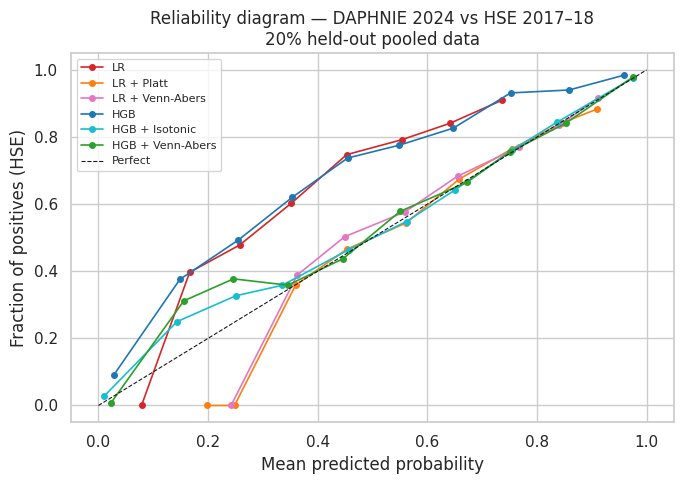


Calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.232,0.241
LR + Platt,0.172,0.010
LR + Venn-Abers,0.172,0.009
HGB,0.173,0.170
HGB + Isotonic,0.134,0.008
HGB + Venn-Abers,0.135,0.013


In [8]:
def ece_score(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — binning-based."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.sum() / n * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


def run_calibration_diagnostics(daphnie_df, hse_df, features):
    """
    Calibration assessment via a stratified 80/20 hold-out split on pooled data.
    Fits all six model variants on the 80% training split; evaluates reliability,
    Brier score, and ECE on the held-out 20%. Diagnostics only — not used for weights.
    """
    src = daphnie_df[features].copy().assign(_label=0)
    tgt = hse_df[features].copy().assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)
    X_all, y_all = pooled[features], pooled["_label"]

    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
    )

    lr_proto = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])
    hgb_proto = HistGradientBoostingClassifier(
        max_iter=300, class_weight="balanced", random_state=42
    )

    diag_models = {
        "LR":               clone(lr_proto),
        "LR + Platt":       CalibratedClassifierCV(clone(lr_proto),  method="sigmoid",  cv=5),
        "LR + Venn-Abers":  VennAbersWrapper(clone(lr_proto),  inductive=False, n_splits=5, shuffle=True, random_state=42),
        "HGB":              clone(hgb_proto),
        "HGB + Isotonic":   CalibratedClassifierCV(clone(hgb_proto), method="isotonic", cv=5),
        "HGB + Venn-Abers": VennAbersWrapper(clone(hgb_proto), inductive=False, n_splits=5, shuffle=True, random_state=42),
    }

    for clf in diag_models.values():
        clf.fit(X_tr, y_tr)

    probs, rows = {}, []
    for name, clf in diag_models.items():
        p = clf.predict_proba(X_cal)[:, 1]
        probs[name] = p
        rows.append({
            "Model":       name,
            "Brier score": brier_score_loss(y_cal, p),
            "ECE":         ece_score(y_cal.values, p),
        })

    return probs, y_cal.values, pd.DataFrame(rows).set_index("Model")


probs, y_cal, cal_metrics = run_calibration_diagnostics(daphnie_24, hse_1718, FEATURES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probs.items():
    frac, mean_pred = calibration_curve(y_cal, p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
            label=name, color=MODEL_COLORS[name])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
ax.set_title("Reliability diagram — DAPHNIE 2024 vs HSE 2017–18\n20% held-out pooled data")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (HSE)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability_restricted.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCalibration metrics (held-out 20%):")
display(cal_metrics.round(4))

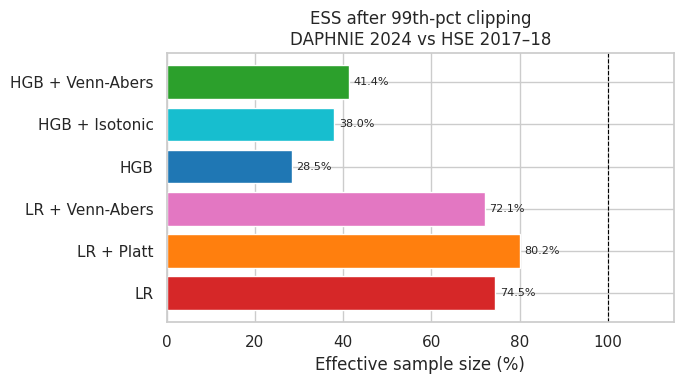

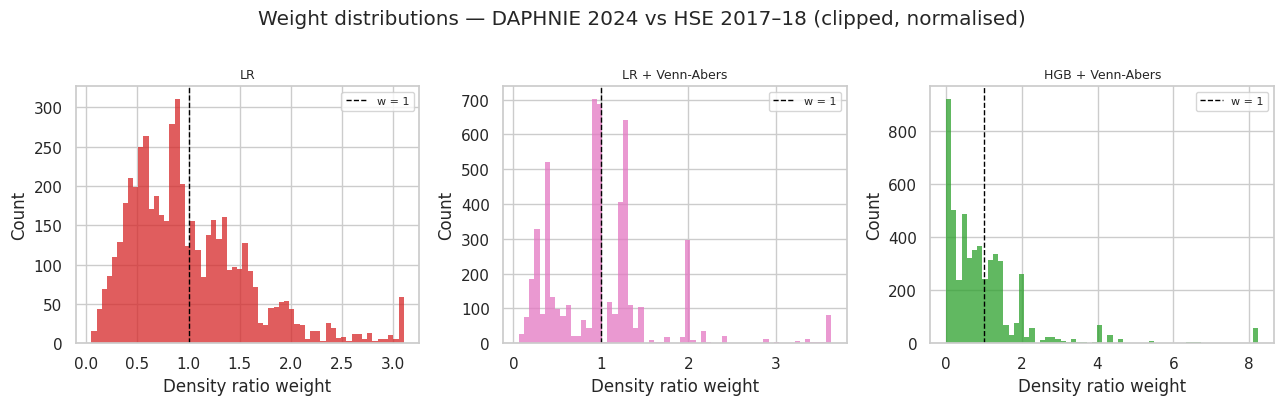

In [9]:
# ESS comparison across all six models
names    = list(weights.keys())
ess_pct  = [weights[n].sum()**2 / (weights[n]**2).sum() / n_src * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effective sample size (%)")
ax.set_title("ESS after 99th-pct clipping\nDAPHNIE 2024 vs HSE 2017–18")
ax.set_xlim(0, 115)
for i, v in enumerate(ess_pct):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison_restricted.png", dpi=150, bbox_inches="tight")
plt.show()

# Weight distributions — LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, KEY_DIST):
    w = weights[name]
    ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Density ratio weight")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Weight distributions — DAPHNIE 2024 vs HSE 2017–18 (clipped, normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions_restricted.png", dpi=150, bbox_inches="tight")
plt.show()

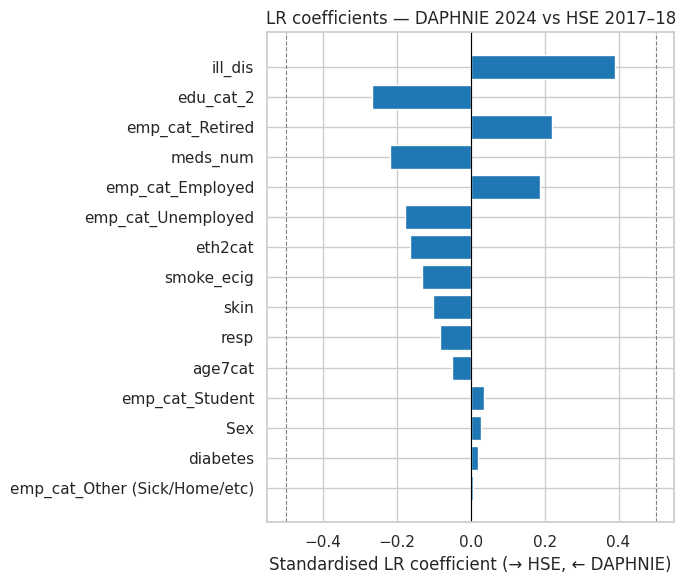

LR coefficients (standardised):


,coefficient,|coefficient|
ill_dis,0.391,0.391
edu_cat_2,-0.266,0.266
emp_cat_Retired,0.221,0.221
meds_num,-0.219,0.219
emp_cat_Employed,0.187,0.187
emp_cat_Unemployed,-0.177,0.177
eth2cat,-0.163,0.163
smoke_ecig,-0.132,0.132
skin,-0.102,0.102
resp,-0.083,0.083


In [10]:
# LR coefficient inspection
clf  = models["LR"].named_steps["clf"]
coef = pd.Series(clf.coef_[0], index=FEATURES).sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]

fig, ax = plt.subplots(figsize=(7, max(5, len(FEATURES) * 0.4)))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")
ax.set_title("LR coefficients — DAPHNIE 2024 vs HSE 2017–18")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients_restricted.png", dpi=150, bbox_inches="tight")
plt.show()

tbl = (
    pd.DataFrame({
        "coefficient":   clf.coef_[0],
        "|coefficient|": np.abs(clf.coef_[0]),
    }, index=FEATURES)
    .sort_values("|coefficient|", ascending=False)
)
print("LR coefficients (standardised):")
display(tbl.round(3))

In [11]:
# Balance check: FEATURES + alcohol_yr as diagnostic
# alcohol_yr is not in the model but included here to show whether the
# skip-logic imbalance is incidentally corrected or worsened by the weights.
BALANCE_VARS = FEATURES + (["alcohol_yr"] if "alcohol_yr" in df.columns else [])
KEY_BALANCE  = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = hse_1718["wt_int"].fillna(1.0)
svy_wt = daphnie_24["svy_wt"].fillna(1.0)

smds = {}
for col in BALANCE_VARS:
    row = {"Before": compute_smd(daphnie_24[col], svy_wt, hse_1718[col], hse_wt)}
    for name in KEY_BALANCE:
        w = weights[name]
        row[f"After: {name}"] = compute_smd(daphnie_24[col], svy_wt * w, hse_1718[col], hse_wt)
    smds[col] = row

balance = pd.DataFrame(smds).T

print("Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:")
display(
    balance.dropna(how="all")
    .sort_values("Before", key=abs, ascending=False)
    .round(3)
)

Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
alcohol_yr,-0.878,-0.844,-0.842,-0.861,-0.847
edu_cat_2,0.264,-0.035,-0.031,0.009,0.006
emp_cat_Unemployed,0.225,-0.015,-0.022,0.010,0.017
eth2cat,0.181,-0.075,-0.094,-0.077,-0.104
ill_dis,-0.152,0.127,0.147,0.124,0.126
skin,0.097,-0.008,-0.025,0.007,-0.001
emp_cat_Employed,-0.079,-0.046,-0.054,-0.084,-0.113
smoke_ecig,0.075,-0.021,-0.016,-0.051,-0.042
emp_cat_Student,-0.062,-0.111,-0.104,-0.166,-0.170
emp_cat_Other (Sick/Home/etc),0.051,0.039,0.039,0.024,0.028


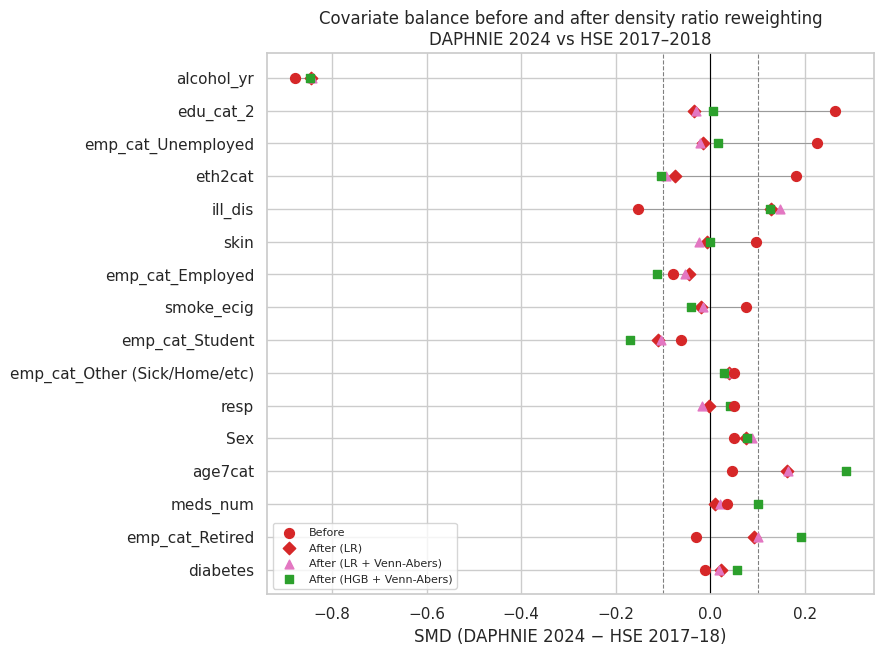

Balance on model features (15 variables):
  Before:              4 variables |SMD| > 0.1
  After (LR                    ): 3 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 4 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 7 variables |SMD| > 0.1

alcohol_yr (diagnostic only, not in model):
  Before                             : SMD = -0.878
  After: LR                          : SMD = -0.844
  After: LR + Venn-Abers             : SMD = -0.842
  After: HGB + Venn-Abers            : SMD = -0.847


In [12]:
# Love plot — Before vs LR, LR+VA, HGB+VA
KEY_LOVE     = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

tbl_plot = balance.dropna(subset=["Before"]).copy()
order    = tbl_plot["Before"].abs().sort_values().index
y_pos    = np.arange(len(order))
before   = tbl_plot.loc[order, "Before"]

fig, ax = plt.subplots(figsize=(9, max(6, len(order) * 0.42)))
ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

for name in KEY_LOVE:
    col   = f"After: {name}"
    after = tbl_plot.loc[order, col]
    ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
               marker=LOVE_MARKERS[name], label=f"After ({name})")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate balance before and after density ratio reweighting\nDAPHNIE 2024 vs HSE 2017–2018")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting_restricted.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
model_vars = [c for c in balance.index if c != "alcohol_yr"]
print(f"Balance on model features ({len(model_vars)} variables):")
print(f"  Before:              {balance.loc[model_vars, 'Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
for name in KEY_LOVE:
    col = f"After: {name}"
    print(f"  After ({name:<22}): {balance.loc[model_vars, col].abs().gt(0.1).sum()} variables |SMD| > 0.1")
if "alcohol_yr" in balance.index:
    print(f"\nalcohol_yr (diagnostic only, not in model):")
    for col in ["Before"] + [f"After: {n}" for n in KEY_LOVE]:
        print(f"  {col:<35}: SMD = {balance.loc['alcohol_yr', col]:.3f}")